# Non-linear equations

**Table of contents**<a id='toc0_'></a>    
- 1. [Introduction](#toc1_)    
- 2. [Derivative based methods](#toc2_)    
- 3. [Numerical derivative](#toc3_)    
- 4. [Derivative free methods: Bisection](#toc4_)    
- 5. [Root-Finding using Scipy](#toc5_)    
- 6. [The Consumer Problem (again)](#toc6_)    
  - 6.1. [Newton's Method](#toc6_1_)    
  - 6.2. [Bisection](#toc6_2_)    
- 7. [Takeaways](#toc7_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

You will learn to find roots of non-linear equations numerically (**scipy.optimize**).

**scipy.optimize:** [overview](https://docs.scipy.org/doc/scipy/reference/optimize.html) + [tutorial](https://docs.scipy.org/doc/scipy/tutorial/optimize.html)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size': 14})

import ipywidgets as widgets

from scipy import optimize

**Note:** The algorithms written here are meant to be illustrative. The scipy implementations are always both the *fastest* and the *safest* choice.

## 1. <a id='toc1_'></a>[Introduction](#toc0_)

In economics, we really like setting **First Order Conditions** to 0. We do it every time we want to solve for optimal behavior.

Therefore, we often want to **solve non-linear equations** of the form

$$ 
f(x) = 0, \quad x \in \mathbb{R} 
$$

There are 2 types of method:
* **Derivative based:** More robust and takes **fewer** steps.
* **Derivative free:** Less numerically stable, but does not require a gradient, so often easier to implement.

A simple **example** of a function for our root finding:

$$
f(x) = -x^3 + 2x^2 + 4x + 30 
$$

## 2. <a id='toc2_'></a>[Derivative based methods](#toc0_)

**Newton's method**: 

We use a **first order** Taylor approximation of the function at a **new point** $x_1$:

$$ 
f(x_1) \approx f(x_0) + f^{\prime}(x_0)(x_1-x_0)
$$

We choose $x_1$ where the Taylor approximation is zero: 

$$
f(x_1) = 0 \Leftrightarrow x_1 = x_0 - \frac{f(x_0)}{f^{\prime}(x_0)}
$$

**Algorithm:** `find_root()`

1. Choose tolerance $\epsilon > 0$, guess on $x_0$ and set $k = 0$.
2. Calculate $f(x_k)$ and $f^{\prime}(x_k)$.
3. If $|f(x_k)| < \epsilon$ then stop.
4. Calculate new candidate $x_{k+1} = x_k - \frac{f(x_k)}{f^{\prime}(x_k)}$.
5. Set $k = k + 1$ and return to step 2.

In [2]:
def find_root(x0,f,df,max_iter=500,tol=1e-8,full_info=False):
    """ find root
        
    Args:
    
        x0 (float): initial value
        f (callable): function
        df (callable): derivative
        max_iter (int): maximum number of iterations
        tol (float): tolerance
        full_info (bool): controls information returned
        
    Returns:
    
        x (float/ndarray): root (if full_info, all x tried)
        k (int): number of iterations used
        fx (ndarray): function values used (if full_info) 
        fpx (ndarray): derivative values used (if full_info)
        
    """
    
    xs, fxs, dfxs = [], [], []
    x_k = x0
    k = 0
    
    while True:
        
        x = x_k

        # step 2: evaluate function and derivative
        fx  = f(x)
        dfx = df(x)
        
        xs.append(x); fxs.append(fx); dfxs.append(dfx)

        # step 3: check convergence
        if abs(fx) < tol or k >= max_iter:
            break
            
        # step 4: update
        x_k = x - fx/dfx
        
        # step 5: increment
        k += 1
        
    if full_info:
        return np.array(xs), k, np.array(fxs), np.array(dfxs)
    else:
        return x, k

In [3]:
def plot_find_root(x0,f,fp,xmin=-8,xmax=8,xn=100):
    
    # a. find root and return all information 
    x,max_iter,fx,fpx = find_root(x0,f,df=fp,full_info=True)
    
    # b. compute function on grid
    xvec = np.linspace(xmin,xmax,xn)
    fxvec = f(xvec)
    
    # c. figure
    def _figure(k):
        
        # i. here we have the linear (first order) taylor approximation (=tangent line at x_k)
        fapprox = fx[k] + fpx[k]*(xvec-x[k]) 
            
        # ii. figure
        fig = plt.figure(figsize=(15,5))
        ax = fig.add_subplot(1,1,1)
        
        ax.plot(xvec,fxvec) # the true f(x)
        ax.plot(x[k],0,'o',color='blue',mfc='none',label='$x_{k}$')#  current iterate x_k on x-axis
        ax.plot(xvec,fapprox) # tangent line at x_k
        ax.plot(x[k],fx[k],'o',color='black',label='$f(x_k)$') # the point (x_k, f(x_k))       

        ax.axhline(0,ls='-',lw=1,color='black') # coordinate system
        ax.axvline(0,ls='-',lw=1,color='black') # coordinate system
        
        # if there IS a next iterate, plot it
        if k+1 < len(x):
            ax.axvline(x[k+1],ls='--',lw=1,color='black') # cross zero: dashed vertical line
            ax.plot(x[k+1],0,'o',color='green',mfc='none',label='$x_{k+1}$') # next

        # cosmetics        
        ax.legend(loc='upper left',facecolor='white',ncols=3,frameon=True)
        ax.set_ylim(min([fxvec[-1],fxvec[0]]),max([fxvec[-1],fxvec[0]]))

        fig.tight_layout()
    
    # this gives us an iteration slider to animate the method.
    widgets.interact(_figure,
        k=widgets.IntSlider(description='iterations', min=0, max=max_iter, step=1, value=0)
    );

Run and plot:

In [4]:
f  = lambda x: -x**3 + 2*x**2 + 4*x + 30
df = lambda x: -3*x**2 + 4*x + 4
x0 = -5.0

x, k = find_root(x0, f, df)
print(f'x = {x:.8f} [iterations: {k}]')
print(f'f(x) = {f(x)}')

x = 4.43084740 [iterations: 7]
f(x) = -2.3284130179490603e-10


In [5]:
plot_find_root(x0,f,df)

interactive(children=(IntSlider(value=0, description='iterations', max=7), Output()), _dom_classes=('widget-in…

## 3. <a id='toc3_'></a>[Numerical derivative](#toc0_)

Sometimes, you might not have the **analytical derivative**. Then, you can instead use the **numerical derivative**.

**Numerical derivative:** Define $\Delta$ to be a small number, then we approximate the derivative by 
$$
 \frac{df}{dx} \approx \frac{f(x+\Delta) - f(x)}{\Delta}
$$

In [6]:
# a. numerical derivative (forward)
Delta = 1e-8
fp_approx = lambda x: (f(x+Delta)-f(x))/Delta

# b. find root
x0 = -5.0
x,k = find_root(x0,f,fp_approx,max_iter=200)   
print(f'x = {x:.8f} [iterations: {k}]')
print(f'f(x) = {f(x)}')

x = 4.43084740 [iterations: 7]
f(x) = -2.374527241499891e-10


**Question:** What happens if you reduce the number of maximum iterations?  

**Question:** What happens if you choose a different starting value x0?

## 4. <a id='toc4_'></a>[Derivative free methods: Bisection](#toc0_)

Bisection is, like Newton's, an important root finding algorithm.

- If $f$ is continuous and $f(a)\cdot f(b)<0$, the function changes sign on $[a,b]$, so it must cross the x-axis somewhere in between (Intermediate Value Theorem).

- Bisection uses this: set $m=\tfrac{a+b}{2}$; keep the half-interval where the sign change persists (i.e., where $f(\cdot)$ flips sign); repeat.

- Each step halves the interval length, giving a guaranteed, steadily tightening bracket around a root — slower than Newton, but highly reliable.

- Requirements/caveats: continuity on $[a,b]$; a sign change guarantees at least one root (possibly more); "touching" roots without sign change won't be captured.

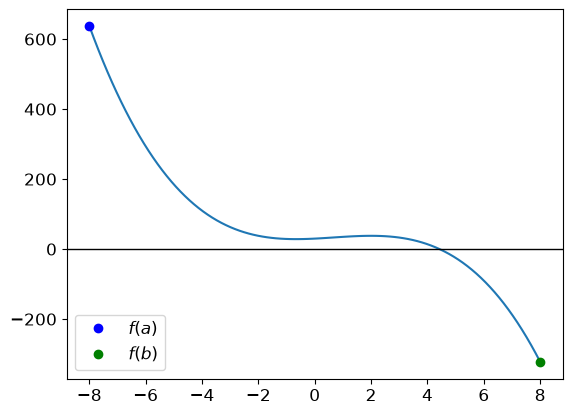

In [7]:
# a. x-values and function-values
xs = np.linspace(-8,8,100)
ys = f(xs)

# b. figure
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(xs,ys)
ax.axhline(0, ls='-',lw=1,color='black')
ax.plot(xs[0],ys[0],'o',color='blue',label='$f(a)$')
ax.plot(xs[-1],ys[-1],'o',color='green',label='$f(b)$')
ax.legend(loc='lower left',facecolor='white',frameon=True);
ax.grid(visible=None)

**Algorithm:** `bisection()`

1. Set $a_0 = a$ and $b_0 = b$ where $f(a)$ and $f(b)$ have opposite sign, $f(a_0)f(b_0)<0$
2. Compute $f(m_0)$ where $m_0 = (a_0 + b_0)/2$ is the midpoint.
3. Determine the next sub-interval $[a_1,b_1]$:
  * If $f(a_0)f(m_0) < 0$ (different signs) then $a_1 = a_0$ and $b_1 = m_0$ (i.e. focus on $[a_0,m_0]$).
  * If $f(m_0)f(b_0) < 0$ (different signs) then $a_1 = m_0$ and $b_1 = b_0$ (i.e. focus on $[m_0,b_0]$).
4. Repeat steps 2–3 until $|f(m_k)| < \epsilon$.

In [8]:
def bisection(f,a,b,max_iter=500,tol=1e-8,full_info=False):
    """ bisection
    
    Solve equation f(x) = 0 for a <= x <= b.
    
    Args:
    
        f (callable): function
        a (float): left bound
        b (float): right bound
        max_iter (int): maximum number of iterations
        tol (float): tolerance on solution
        full_info (bool): controls information returned
        
    Returns:
    
        m (float/ndarray): root (if full_info, all x tried)
        k (int): number of iterations used
        a (ndarray): left bounds used
        b (ndarray): right bounds used
        fm (ndarray): function values at midpoints
        
    """
    
    if f(a)*f(b) >= 0:
        print('bisection method fails.')
        return None
    
    a_l, b_l, m_l, fm_l = [], [], [], []
    k = 0
    
    while k < max_iter:
        
        # step 2: midpoint
        m  = (a+b)/2
        fm = f(m)
        
        a_l.append(a); b_l.append(b); m_l.append(m); fm_l.append(fm)
        
        # step 3: keep half with sign change
        if abs(fm) < tol:
            break        
        elif f(a)*fm < 0:  # keep left half
            b = m
        elif f(b)*fm < 0:  # keep right half
            a = m
        else:
            print('bisection method fails.')
            return None
        
        k += 1
        
    if full_info:
        return np.array(m_l), k, np.array(a_l), np.array(b_l), np.array(fm_l)
    else:
        return m, k

In [9]:
m,k = bisection(f,-8,8)
print(k,m,f(m))

33 4.430847399868071 4.316270008075662e-09


**Same result** as before, but **trade-off** between more iterations and no evaluation of derivatives.

In [10]:
def plot_bisection(f,a,b,xmin=-8,xmax=8,xn=100):
    
    # a. find root and return all information 
    res = bisection(f,a,b,full_info=True)
    if res is None:
        return
    m,max_iter,a,b,fm = res
    
    # b. compute function on grid
    xvec = np.linspace(xmin,xmax,xn)
    fxvec = f(xvec)
    
    # c. figure
    def _figure(k):
        fig = plt.figure(figsize=(15,5))
        ax = fig.add_subplot(1,1,1)
        
        ax.plot(xvec,fxvec)
        ax.axhline(0, color='black')
        ax.plot(m[k],fm[k],'o',color='black',label='current')
        ax.plot([a[k],b[k]],[fm[k],fm[k]],'--',color='green',label='range')
        ax.axvline(a[k],ls='--',color='green')
        ax.axvline(b[k],ls='--',color='green')        
        
        ax.legend(loc='lower left',facecolor='white',frameon=True)
        ax.set_ylim(min([fxvec[-1],fxvec[0]]),max([fxvec[-1],fxvec[0]]))
    
    widgets.interact(_figure,
        k=widgets.IntSlider(description='iterations', min=0, max=max_iter-1, step=1, value=0)
    );

plot_bisection(f,-8,8)

interactive(children=(IntSlider(value=0, description='iterations', max=32), Output()), _dom_classes=('widget-i…

**Note:** Bisection is not good at the final convergence steps. Generally true for methods not using derivatives.

## 5. <a id='toc5_'></a>[Root-Finding using Scipy](#toc0_)

Scipy, naturally, has better implementations of the above algorithms. 

You will most likely want to go for these when doing your own model solution.

**Newton:**

In [11]:
result = optimize.root_scalar(f,x0=-5.0,fprime=df,method='newton')
print(result)

      converged: True
           flag: converged
 function_calls: 16
     iterations: 8
           root: 4.430847399984182
         method: newton


**Bisect:**

In [12]:
result = optimize.root_scalar(f,bracket=[-8,8],method='bisect')
print(result)

      converged: True
           flag: converged
 function_calls: 45
     iterations: 43
           root: 4.430847399982667
         method: bisect


The **best choice** is the more advanced **Brentq-method** (combines bisection and interpolation methods; thus robustness and speed):

In [13]:
result = optimize.root_scalar(f,bracket=[-8,8],method='brentq')
print(result)

      converged: True
           flag: converged
 function_calls: 13
     iterations: 12
           root: 4.430847399984182
         method: brentq


## 6. <a id='toc6_'></a>[The Consumer Problem (again)](#toc0_)

We revisit a two-good Cobb–Douglas consumer to illustrate **bisection** and **Newton's method** on a **one-dimensional** root.

**Setup.** $u(x_1,x_2)=x_1^{\alpha}x_2^{1-\alpha}$ with $0<\alpha<1$; budget $p_1x_1+p_2x_2\le I$, $x_1,x_2\ge 0$.

**On the budget line**
$$
x_2(x_1)=\frac{I-p_1x_1}{p_2},\qquad 0<x_1<\frac{I}{p_1}.
$$

**First-order Condition**
$$
f(x_1)\;\equiv\;\frac{\alpha}{x_1}-\frac{(1-\alpha)p_1}{I-p_1x_1}\;=\;0,
\qquad 0<x_1<\frac{I}{p_1}.
$$

**Bisection (robust).** Choose a small $\varepsilon>0$ and bracket
$[a,b]=[\varepsilon,\ I/p_1-\varepsilon]$ with $f(a)\cdot f(b)<0$.
Repeatedly set $m=\tfrac{a+b}{2}$ and keep the half where the sign change persists
until the interval is tiny.

**Newton (fast, needs a good start).** Iterate
$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)},\qquad
f'(x_1)=-\frac{\alpha}{x_1^2}-\frac{(1-\alpha)p_1^2}{(I-p_1x_1)^2},
$$
starting from an interior guess (e.g., $x_1^{(0)}=I/(2p_1)$) and ensuring $x_k\in(0,I/p_1)$.

**Sanity check (closed form)**
$$
x_1^*=\frac{\alpha I}{p_1},\qquad x_2^*=\frac{(1-\alpha)I}{p_2}.
$$


In [14]:
# Parameters (change as needed)
alpha = 0.5  # preference weight on good 1
p1 = 1.0     # price of good 1
p2 = 2.0     # price of good 2
I  = 10.0    # income

def x2_of(x1):
    """Budget-implied x2."""
    return (I - p1*x1)/p2

# FOC: alpha/x1 - (1-alpha)*p1/(I-p1*x1) = 0
def F(x1, alpha=alpha, I=I, p1=p1):
    return alpha/x1 - (1 - alpha)*p1/(I - p1*x1)

def Fprime(x1, alpha=alpha, I=I, p1=p1):
    return -alpha/(x1**2) - (1 - alpha)*(p1**2)/((I - p1*x1)**2)

# Closed-form demands
x1_star_closed = alpha*I/p1
x2_star_closed = (1-alpha)*I/p2
x1_star_closed, x2_star_closed

(5.0, 2.5)

### 6.1. <a id='toc6_1_'></a>[Newton's Method](#toc0_)

Newton uses the derivative $f'(x_1)=-\frac{\alpha}{x_1^2}-\frac{(1-\alpha)p_1^2}{(I-p_1x_1)^2}$.
We keep iterates inside $(0, I/p_1)$ via a simple backtracking rule.


In [15]:
# a. initial guess and solve
x0 = 0.4*(I/p1)
x1_newt, it_newt = find_root(x0, F, Fprime, tol=1e-12)
x2_newt = x2_of(x1_newt)

# b. report
print(f"Newton:     x1*={x1_newt:.10f}, x2*={x2_newt:.10f}, iterations={it_newt}")
print(f"Closed-form x1*={x1_star_closed:.10f} (abs err {abs(x1_newt - x1_star_closed):.2e})")

Newton:     x1*=5.0000000000, x2*=2.5000000000, iterations=3
Closed-form x1*=5.0000000000 (abs err 3.55e-15)


### 6.2. <a id='toc6_2_'></a>[Bisection](#toc0_)

Bisection needs a bracket $[a,b]$ with **opposite signs** $F(a)\cdot F(b)<0$. 
For this problem, any $a\in(0,\alpha I/p_1)$ and $b\in(\alpha I/p_1, I/p_1)$ works.

In [16]:
# a. bracket and solve
a_bis = 1e-4; b_bis = I/p1 - 1e-4  # symmetric bracket

x1_bis, it_bis = bisection(F, a_bis, b_bis, tol=1e-15, max_iter=500)
x2_bis = (I - p1*x1_bis)/p2

# b. report
print(f"Bisection:  x1*={x1_bis:.10f}, x2*={x2_bis:.10f}, iterations={it_bis}")
print(f"Closed-form x1*={x1_star_closed:.10f} (abs err {abs(x1_bis - x1_star_closed):.2e})")

Bisection:  x1*=5.0000000000, x2*=2.5000000000, iterations=0
Closed-form x1*=5.0000000000 (abs err 0.00e+00)


Since $F(5)=0$, bisection terminates at the first midpoint — the output shows `iterations = 0`.

Using an asymmetric bracket requires more steps:

In [17]:
# a. bracket and solve (asymmetric — more iterations needed)
a_bis = 1e-4
b_bis = 9.7

x1_bis, it_bis = bisection(F, a_bis, b_bis, tol=1e-15, max_iter=500)
x2_bis = (I - p1*x1_bis)/p2

# b. report
print(f"Bisection:  x1*={x1_bis:.10f}, x2*={x2_bis:.10f}, iterations={it_bis}")
print(f"Closed-form x1*={x1_star_closed:.10f} (abs err {abs(x1_bis - x1_star_closed):.2e})")

Bisection:  x1*=5.0000000000, x2*=2.5000000000, iterations=46
Closed-form x1*=5.0000000000 (abs err 2.13e-14)


More iterations are needed — informative bounds (from economic theory) speed things up.


## 7. <a id='toc7_'></a>[Takeaways](#toc0_)
- We transformed the constrained maximization into a **one-dimensional root problem** $F(x_1)=0$.
- **Bisection** is globally robust but slower; **Newton** is fast but needs a reasonable starting point and derivative.
- The numerical solutions match the analytical demands $x_1^*=\alpha I/p_1$, $x_2^*=(1-\alpha)I/p_2$.
